In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'D:\\PythonData'

In [4]:
import os
os.chdir("D:\\PythonData")

In [5]:
os.getcwd()

'D:\\PythonData'

In [6]:
apps_with_duplicates = pd.read_csv("apps.csv")

In [7]:
apps = apps_with_duplicates.drop_duplicates()
print('Total number of apps in the dataset : ', len(apps))
n = 5
apps.sample(n)

Total number of apps in the dataset :  9659


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2365,3028,The Rules of Golf,SPORTS,4.3,926,9.3,"100,000+",Free,0,Everyone,Sports,"January 17, 2018",5.9,4.1 and up
7866,8985,DW,NEWS_AND_MAGAZINES,NaN,0,4.8,"10,000+",Free,0,Everyone 10+,News & Magazines,"July 13, 2018",1.0.5,5.0 and up
1056,1285,Bike Computer - GPS Cycling Tracker,HEALTH_AND_FITNESS,4.4,12029,4.3,"1,000,000+",Free,0,Everyone,Health & Fitness,"August 4, 2018",2.6,4.2 and up
9340,10515,Dino Defends king 3 – Dinosaur T rex Hunter Games,GAME,3.6,182,41.0,"50,000+",Free,0,Teen,Adventure,"March 1, 2018",2.1,4.1 and up
438,508,Free Dating & Flirt Chat - Choice of Love,DATING,4.0,42194,NaN,"5,000,000+",Free,0,Mature 17+,Dating,"July 24, 2018",Varies with device,Varies with device


In [8]:
#clean the data
#remove the characters like + or , or $
chars_to_remove = ['+',',','$']
cols_to_clean = ['Installs','Price']
for col in cols_to_clean:
    for char in chars_to_remove:
        apps[col] = apps[col].apply(lambda x: x.replace(char,""))

print(apps.info())

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB
None


In [9]:
#convert the data types in Install and Price into numeric data types
apps['Installs'] = apps['Installs'].astype(float)
apps['Price'] = apps['Price'].astype(float)
print(apps.dtypes)

Unnamed: 0          int64
App                   str
Category              str
Rating            float64
Reviews             int64
Size              float64
Installs          float64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


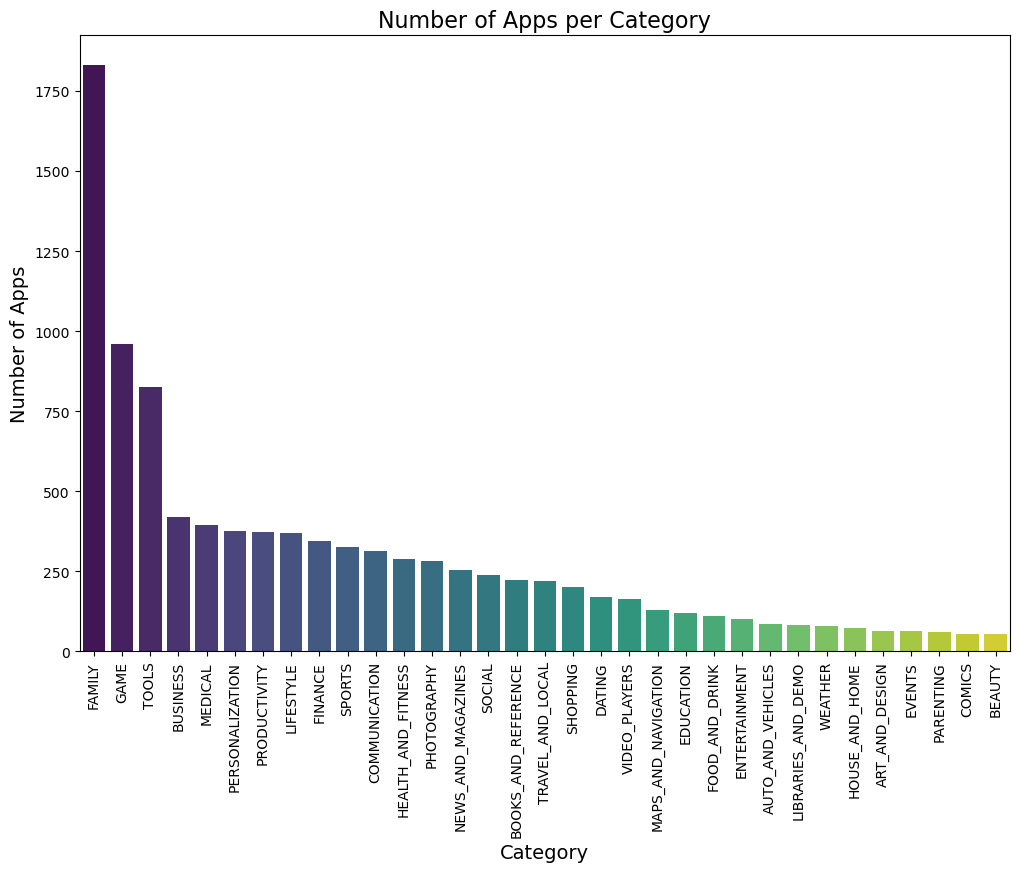

In [10]:
#explore the app categories: which category is the biggest in the market? Is any specific one dominating the market? Which is the most consolidated category?
nums_apps_category = apps['Category'].value_counts()
sorted_nums_apps_category = nums_apps_category.sort_values(ascending=False)
plt.figure(figsize = (12,8))
sns.barplot(x=sorted_nums_apps_category.index, y=sorted_nums_apps_category.values,hue=sorted_nums_apps_category.index,palette='viridis')
plt.title('Number of Apps per Category', fontsize = 16)
plt.xlabel('Category',fontsize = 14)
plt.ylabel('Number of Apps',fontsize = 14)
plt.xticks(rotation = 90)
plt.savefig('appsdistributionn.png', dpi=300, bbox_inches='tight')
plt.show()

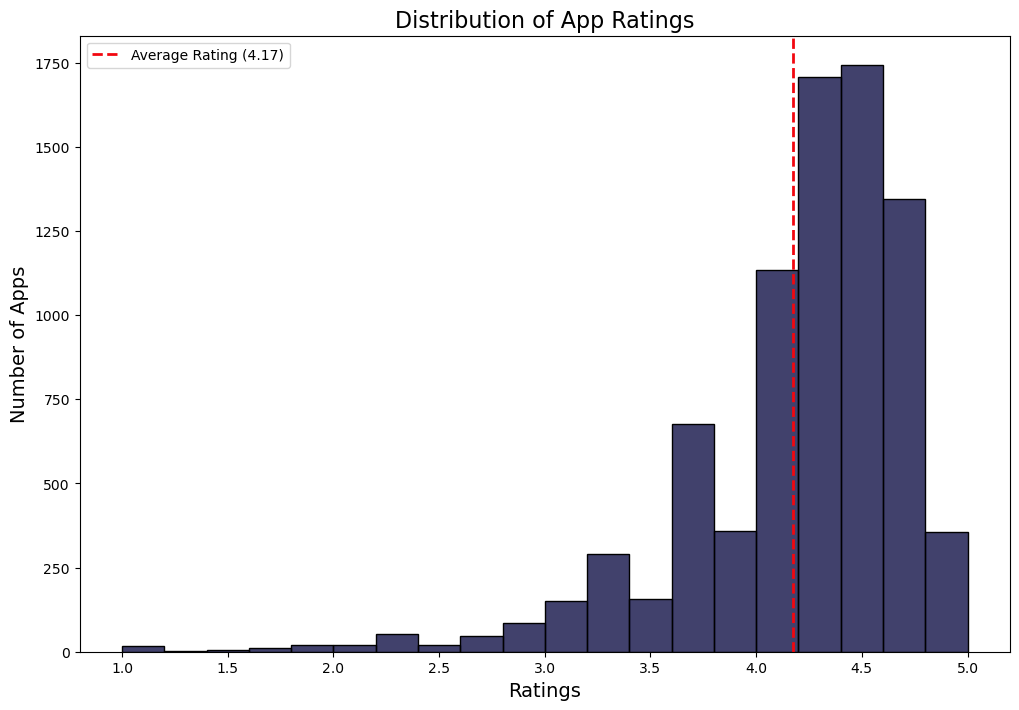

In [11]:
#check the ratings of the apps
avg_ratings = apps['Rating'].mean()
plt.figure(figsize=(12,8))
sns.histplot(apps['Rating'],bins=20,kde=False,color='#01013b')
plt.axvline(avg_ratings, color='#f2070f',linestyle='--',linewidth=2,label=f'Average Rating ({avg_ratings:.2f})')
plt.title('Distribution of App Ratings', fontsize = 16)
plt.xlabel('Ratings',fontsize=14)
plt.ylabel('Number of Apps',fontsize=14)
plt.legend()
plt.savefig('distriapps.png', dpi=300, bbox_inches='tight')
plt.show()

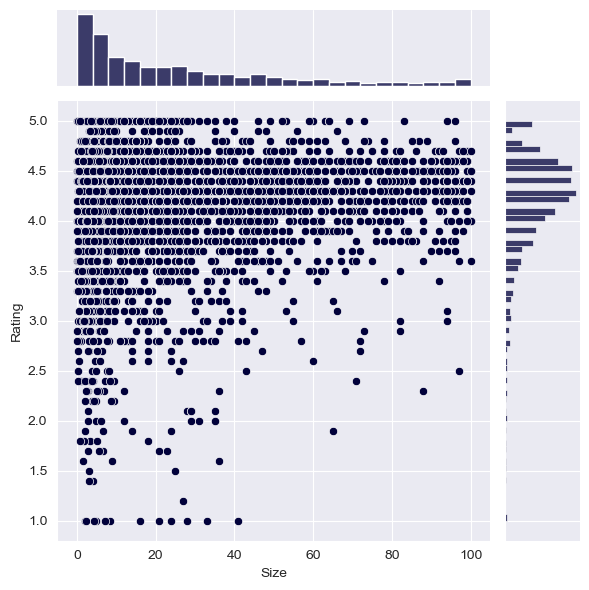

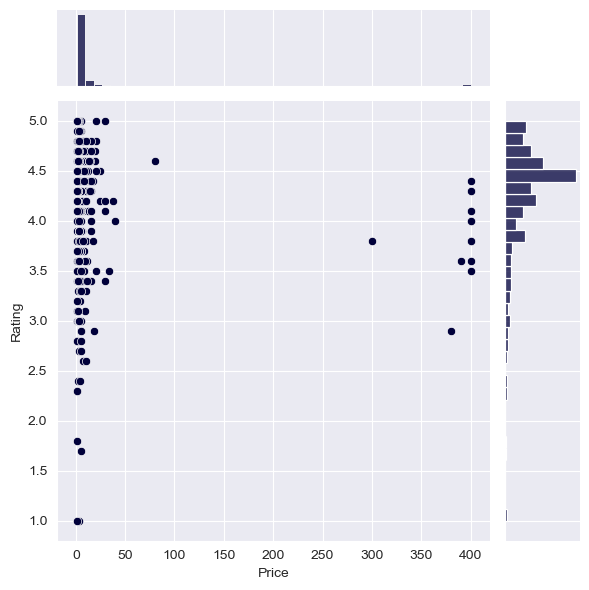

In [12]:
#size and price of apps
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
apps_size_ratings = apps[(~apps['Rating'].isnull()) & (~apps['Size'].isnull())]
large_cat = apps_size_ratings.groupby(['Category']).filter(lambda x: len(x) >= 250)
plt1 = sns.jointplot(x = large_cat['Size'], y = large_cat['Rating'], color = '#01013b')
plt.savefig('pricensize1.png', dpi=300, bbox_inches='tight')
paid_apps = apps_size_ratings[apps_size_ratings['Type'] == 'Paid']
plt2 = sns.jointplot (x = paid_apps['Price'], y = paid_apps['Rating'],color = '#01013b')
plt.savefig('pricensize2.png', dpi=300, bbox_inches='tight')

,Category,App,Price
3327,FAMILY,most expensive app (H),399.99
3465,LIFESTYLE,💎 I'm rich,399.99
3469,LIFESTYLE,I'm Rich - Trump Edition,400.00
4396,LIFESTYLE,I am rich,399.99
4398,FAMILY,I am Rich Plus,399.99
4399,LIFESTYLE,I am rich VIP,299.99
4400,FINANCE,I Am Rich Premium,399.99
4401,LIFESTYLE,I am extremely Rich,379.99
4402,FINANCE,I am Rich!,399.99
4403,FINANCE,I am rich(premium),399.99


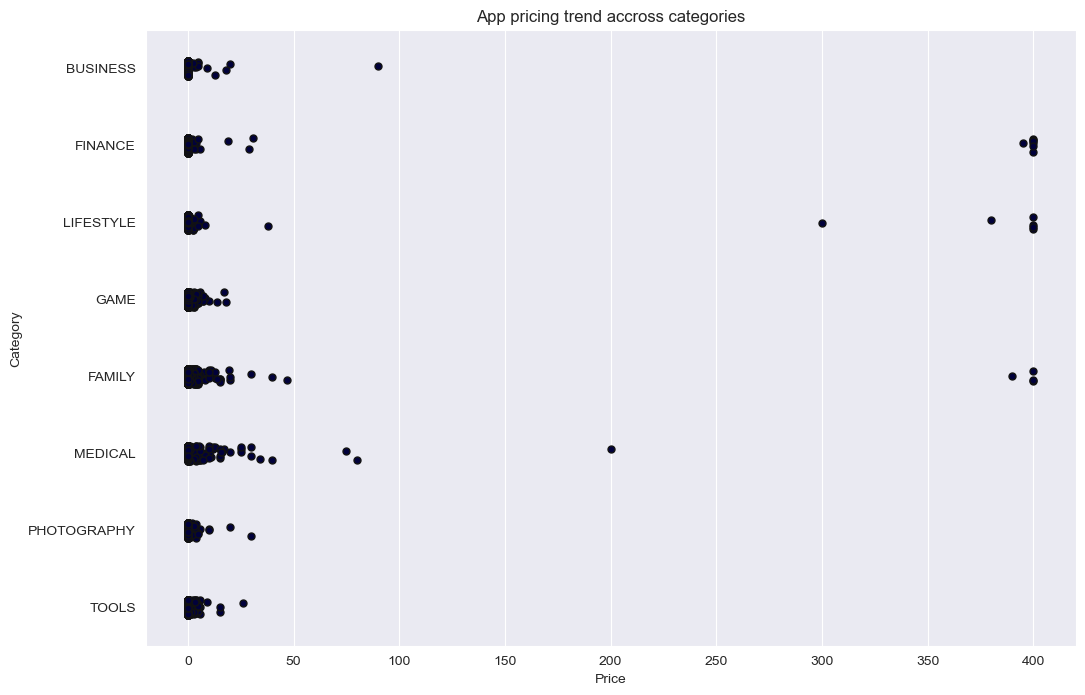

In [13]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

popular_cat = apps[apps.Category.isin(['GAME','FAMILY','PHOTOGRAPHY','MEDICAL','TOOLS','FINANCE','LIFESTYLE','BUSINESS'])]
ax = sns.stripplot(x=popular_cat['Price'],y=popular_cat['Category'],jitter=True,linewidth=1, color='#01013b')
ax.set_title('App pricing trend accross categories')
plt.savefig('pricing_trend.png', dpi=300, bbox_inches='tight')
above_200 = popular_cat[popular_cat['Price'] > 200]
above_200[['Category','App','Price']]

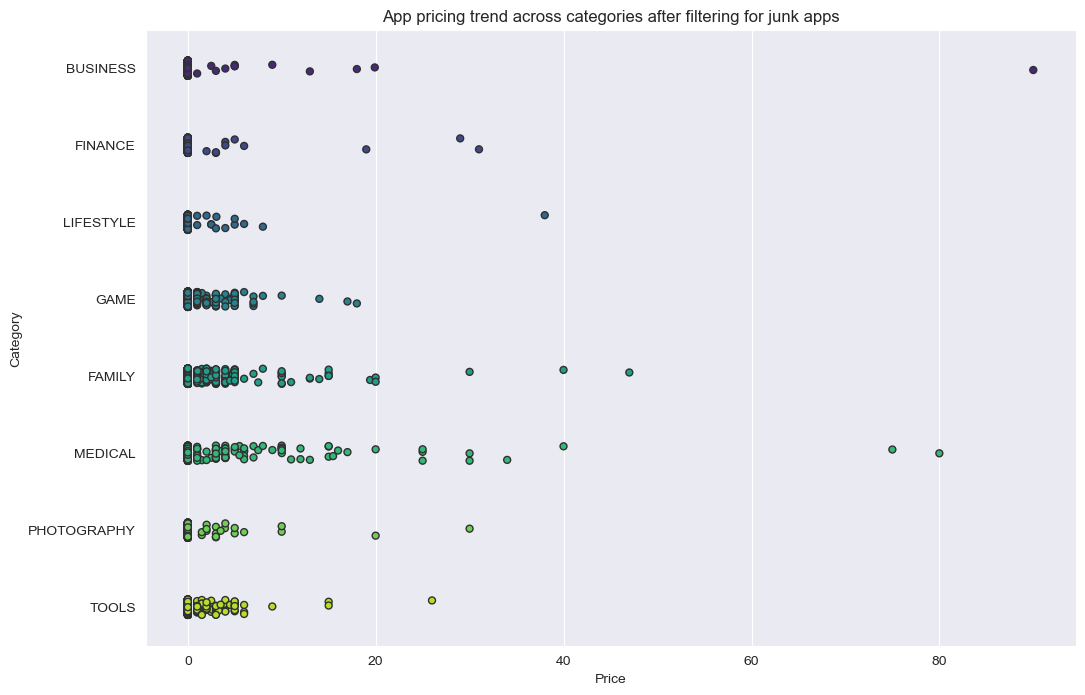

In [14]:
apps_under_100 = popular_cat[popular_cat['Price'] < 100]
fig, ax = plt.subplots()
fig.set_size_inches(12,8)
ax = sns.stripplot(x = 'Price', y = 'Category', data = apps_under_100, jitter = True, linewidth = 1, hue = 'Category', palette='viridis')
ax.set_title('App pricing trend across categories after filtering for junk apps')
plt.savefig('pricing_trend_junks_removed.png', dpi=300, bbox_inches='tight')

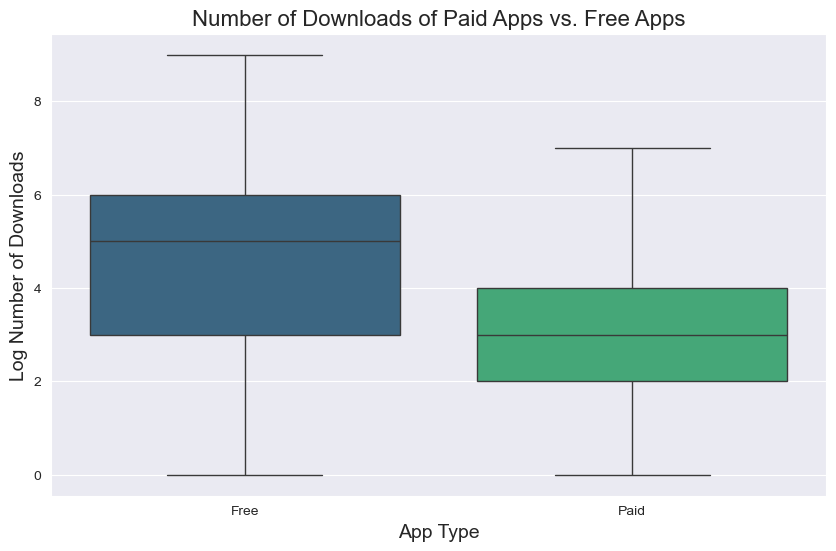

In [15]:
filtered_apps = apps[apps['Installs'] > 0].copy()
filtered_apps.loc[:,'Log_Installs'] = np.log10(filtered_apps['Installs'])
plt.figure(figsize=(10,6))
sns.boxplot(x='Type', y='Log_Installs',data=filtered_apps,hue='Type',palette='viridis')
plt.title('Number of Downloads of Paid Apps vs. Free Apps',fontsize = 16)
plt.xlabel('App Type',fontsize = 14)
plt.ylabel('Log Number of Downloads',fontsize = 14)
plt.show()

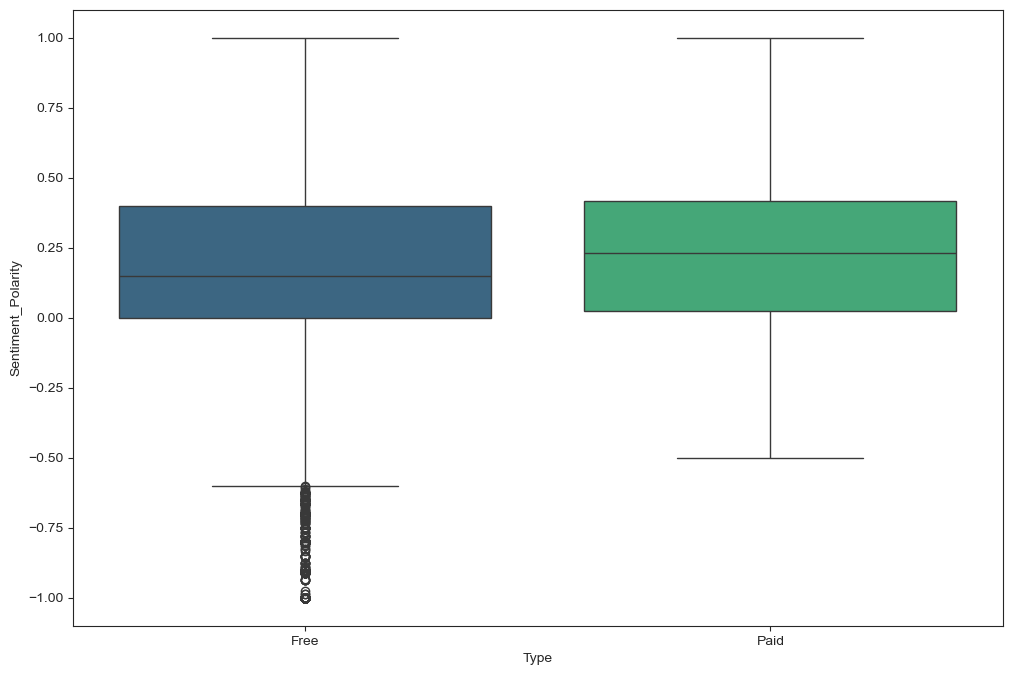

In [16]:
reviews_df = pd.read_csv('user_reviews.csv')
merged_df = pd.merge(apps,reviews_df,on = 'App')
merged_df = merged_df.dropna(subset = ['Sentiment','Review'])
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(12,8)
ax = sns.boxplot(x = 'Type',y='Sentiment_Polarity',data = merged_df,hue='Type',palette='viridis')
ax.set_title=('Sentiment Polarity Distribution')

In [17]:
apps['Installs'] = apps['Installs'].fillna(apps['Installs'].median())

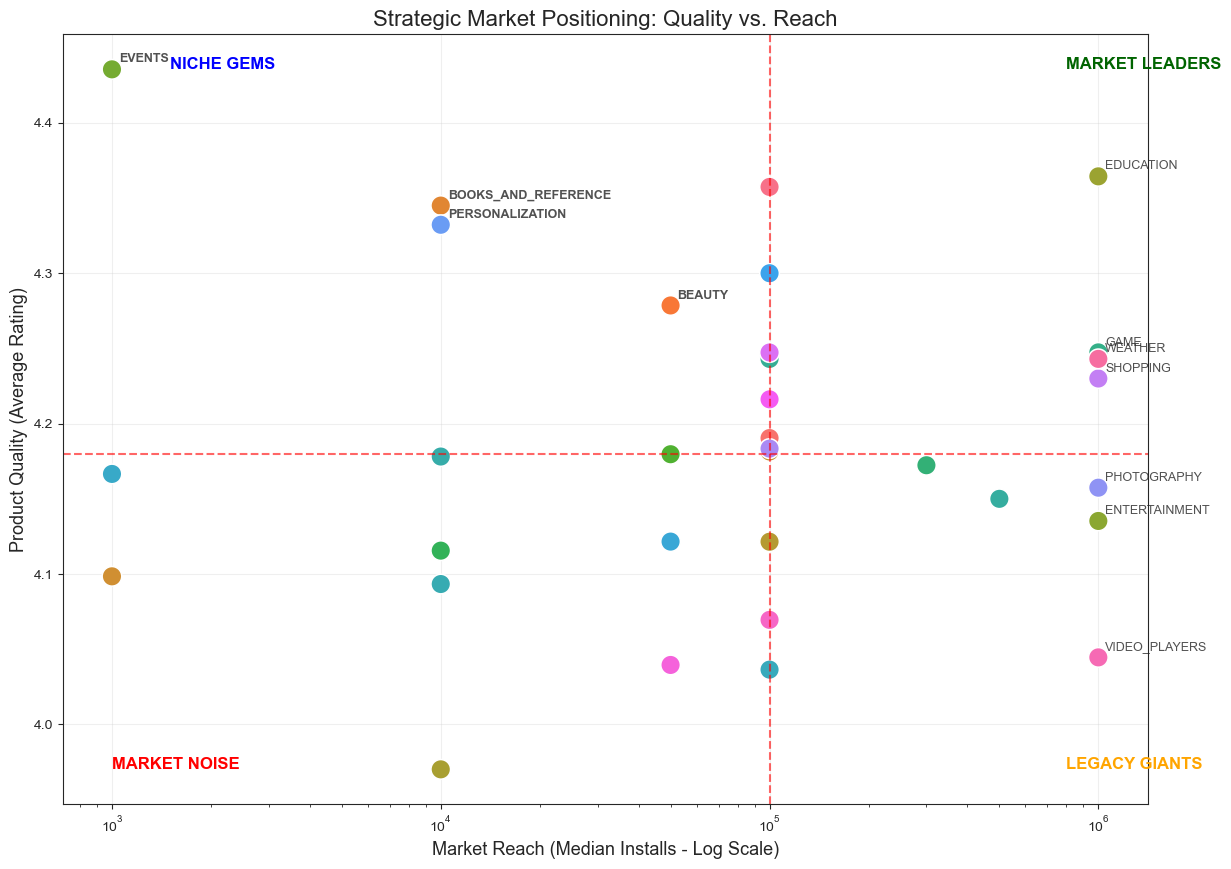

In [30]:
# 1. Market Concentration Analysis (HHI)
# High HHI (>2500) = Concentrated/Monopolized; Low HHI (<1500) = Fragmented/Competitive
def calculate_hhi(data):
    # Calculate market share based on installs
    market_shares = data.groupby('Category')['Installs'].transform(lambda x: (x / x.sum()) * 100)
    # HHI is the sum of squares of market shares
    hhi = (market_shares**2).groupby(data['Category']).sum()
    return hhi

hhi_series = calculate_hhi(apps)

# 2. Competitive Positioning Quadrant Data
# We compare the relative "Quality" (Rating) vs "Market Reach" (Log Installs)
quadrant_data = apps.groupby('Category').agg({
    'Rating': 'mean',
    'Installs': 'median'
}).reset_index()

# 3. Visualization: The Strategic Quadrant
plt.figure(figsize=(14, 10))
sns.scatterplot(data=quadrant_data, x='Installs', y='Rating', s=200, hue='Category', legend=False)

# Draw Median Thresholds to create the 2x2 Matrix
plt.axhline(quadrant_data['Rating'].median(), color='red', linestyle='--', alpha=0.6)
plt.axvline(quadrant_data['Installs'].median(), color='red', linestyle='--', alpha=0.6)

# Annotate the Quadrants 
plt.text(quadrant_data['Installs'].max()*0.8, quadrant_data['Rating'].max(), 'MARKET LEADERS', fontsize=12, fontweight='bold', color='darkgreen')
plt.text(quadrant_data['Installs'].min()*1.5, quadrant_data['Rating'].max(), 'NICHE GEMS', fontsize=12, fontweight='bold', color='blue')
plt.text(quadrant_data['Installs'].max()*0.8, quadrant_data['Rating'].min(), 'LEGACY GIANTS', fontsize=12, fontweight='bold', color='orange')
plt.text(quadrant_data['Installs'].min(), quadrant_data['Rating'].min(), 'MARKET NOISE', fontsize=12, fontweight='bold', color='red')


reach_median = quadrant_data['Installs'].median()
quality_median = quadrant_data['Rating'].median()

# 1. Define your boundaries
reach_median = quadrant_data['Installs'].median()
quality_median = quadrant_data['Rating'].median()

# Define your boundaries first
reach_median = quadrant_data['Installs'].median()
quality_median = quadrant_data['Rating'].median()

for i, txt in enumerate(quadrant_data['Category']):
    # Current values for this specific row
    current_reach = quadrant_data['Installs'].iloc[i]
    current_rating = quadrant_data['Rating'].iloc[i]
    
    # Logic: Label if it's an extreme outlier OR if it falls in the Niche Gem quadrant
    is_extreme = (current_rating > 4.4) or (current_reach > 500000)
    is_niche_gem = (current_reach < reach_median) and (current_rating > quality_median)
    
    if is_extreme or is_niche_gem:
        plt.annotate(txt, 
                     (current_reach, current_rating), 
                     fontsize=9, 
                     alpha=0.8, 
                     fontweight='bold' if is_niche_gem else 'normal', # Bold Niche Gems
                     xytext=(5,5), 
                     textcoords='offset points')
plt.xscale('log')
plt.title('Strategic Market Positioning: Quality vs. Reach', fontsize=16)
plt.xlabel('Market Reach (Median Installs - Log Scale)', fontsize=13)
plt.ylabel('Product Quality (Average Rating)', fontsize=13)
plt.grid(alpha=0.3)
plt.show()

In [31]:
apps['Revenue'] = apps['Installs'] * apps['Price']
apps['Engagement_Ratio'] = apps['Reviews'] / apps['Installs']

reach_median = apps['Installs'].median()
rating_median = apps['Rating'].median()

def segment_apps(row):
    if row['Installs'] >= reach_median and row['Rating'] >= rating_median:
        return 'Market Leader'
    elif row['Installs'] < reach_median and row['Rating'] >= rating_median:
        return 'Niche Gem'
    elif row['Installs'] >= reach_median and row['Rating'] < rating_median:
        return 'Legacy Giant'
    else:
        return 'Market Noise'

apps['Market_Segment'] = apps.apply(segment_apps, axis=1)

apps.to_csv('googleplay_powerbi_ready.csv', index=False)

print("Export Complete: 'googleplay_powerbi_ready.csv' is ready for Power BI.")

Export Complete: 'googleplay_powerbi_ready.csv' is ready for Power BI.


In [32]:
# 1. Calculate the exact Median for Installs (X-Axis)
exact_install_median = apps['Installs'].median()

# 2. Calculate the exact Median for Rating (Y-Axis)
exact_rating_median = apps['Rating'].median()

# 3. Print the results clearly for your Power BI setup
print("-" * 30)
print(f"POWER BI REFERENCE LINE VALUES:")
print("-" * 30)
print(f"X-Axis Constant Line (Installs): {exact_install_median}")
print(f"Y-Axis Constant Line (Rating):   {exact_rating_median:.4f}")
print("-" * 30)

# Optional: If you want to see how many apps fall into your 'Niche Gem' quadrant
niche_gems_count = apps[(apps['Installs'] < exact_install_median) & 
                        (apps['Rating'] > exact_rating_median)].shape[0]

print(f"Total Niche Gems identified: {niche_gems_count}")

------------------------------
POWER BI REFERENCE LINE VALUES:
------------------------------
X-Axis Constant Line (Installs): 100000.0
Y-Axis Constant Line (Rating):   4.3000
------------------------------
Total Niche Gems identified: 1374
